<a href="https://colab.research.google.com/github/shanushafeeh012-arch/Kerala-Flood-Analyses/blob/main/Kerala_floods.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
uploaded = files.upload()  # select kerala.csv from your phone/laptop


Saving kerala.csv to kerala (1).csv


In [ ]:
import pandas as pd
df = pd.read_csv('kerala.csv')
df.head()


,SUBDIVISION,YEAR,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC,ANNUAL RAINFALL,FLOODS
0,KERALA,1901,28.7,44.7,51.6,160.0,174.7,824.6,743.0,357.5,197.7,266.9,350.8,48.4,3248.6,YES
1,KERALA,1902,6.7,2.6,57.3,83.9,134.5,390.9,1205.0,315.8,491.6,358.4,158.3,121.5,3326.6,YES
2,KERALA,1903,3.2,18.6,3.1,83.6,249.7,558.6,1022.5,420.2,341.8,354.1,157.0,59.0,3271.2,YES
3,KERALA,1904,23.7,3.0,32.2,71.5,235.7,1098.2,725.5,351.8,222.7,328.1,33.9,3.3,3129.7,YES
4,KERALA,1905,1.2,22.3,9.4,105.9,263.3,850.2,520.5,293.6,217.2,383.5,74.4,0.2,2741.6,NO


In [ ]:
print("Shape:", df.shape)
print("\nStatistics:\n")
print(df.describe())


Shape: (118, 16)

Statistics:

              YEAR         JAN         FEB         MAR         APR  \
count   118.000000  118.000000  118.000000  118.000000  118.000000   
mean   1959.500000   12.218644   15.633898   36.670339  110.330508   
std      34.207699   15.473766   16.406290   30.063862   44.633452   
min    1901.000000    0.000000    0.000000    0.100000   13.100000   
25%    1930.250000    2.175000    4.700000   18.100000   74.350000   
50%    1959.500000    5.800000    8.350000   28.400000  110.400000   
75%    1988.750000   18.175000   21.400000   49.825000  136.450000   
max    2018.000000   83.500000   79.000000  217.200000  238.000000   

              MAY          JUN          JUL          AUG         SEP  \
count  118.000000   118.000000   118.000000   118.000000  118.000000   
mean   228.644915   651.617797   698.220339   430.369492  246.207627   
std    147.548778   186.181363   228.988966   181.980463  121.901131   
min     53.400000   196.800000   167.500000   178.

Missing Values:
 SUBDIVISION         0
YEAR                0
JAN                 0
FEB                 0
MAR                 0
APR                 0
MAY                 0
JUN                 0
JUL                 0
AUG                 0
SEP                 0
OCT                 0
NOV                 0
DEC                 0
 ANNUAL RAINFALL    0
FLOODS              0
dtype: int64


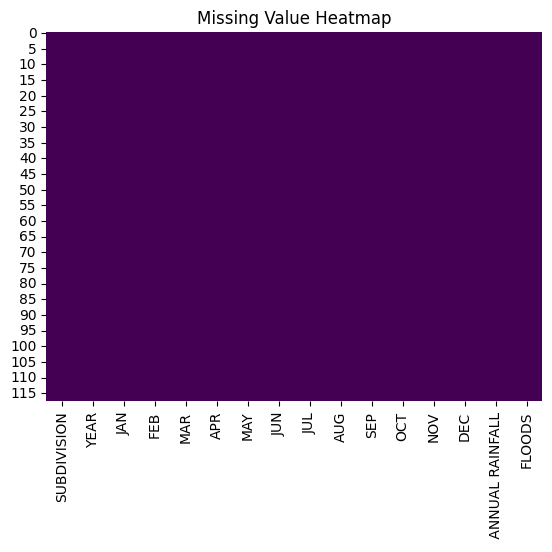

In [ ]:
print("Missing Values:\n", df.isnull().sum())

sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Value Heatmap')
plt.show()


/tmp/ipykernel_5224/1422787955.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='FLOODS', data=df, palette='Set2')


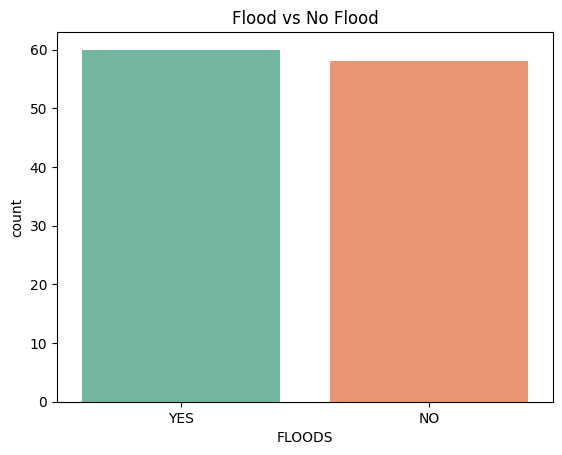

In [ ]:
sns.countplot(x='FLOODS', data=df, palette='Set2')
plt.title('Flood vs No Flood')
plt.show()


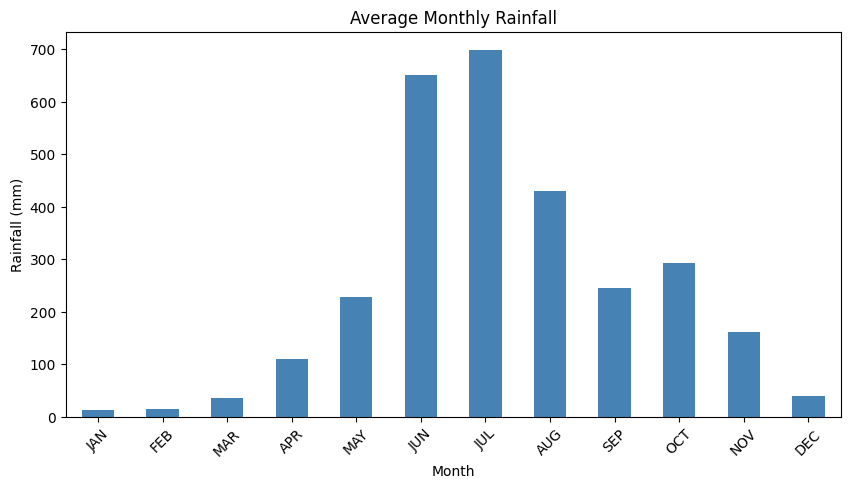

In [ ]:
months = ['JAN','FEB','MAR','APR','MAY','JUN',
          'JUL','AUG','SEP','OCT','NOV','DEC']

df[months].mean().plot(kind='bar', color='steelblue', figsize=(10,5))
plt.title('Average Monthly Rainfall')
plt.xlabel('Month')
plt.ylabel('Rainfall (mm)')
plt.xticks(rotation=45)
plt.show()


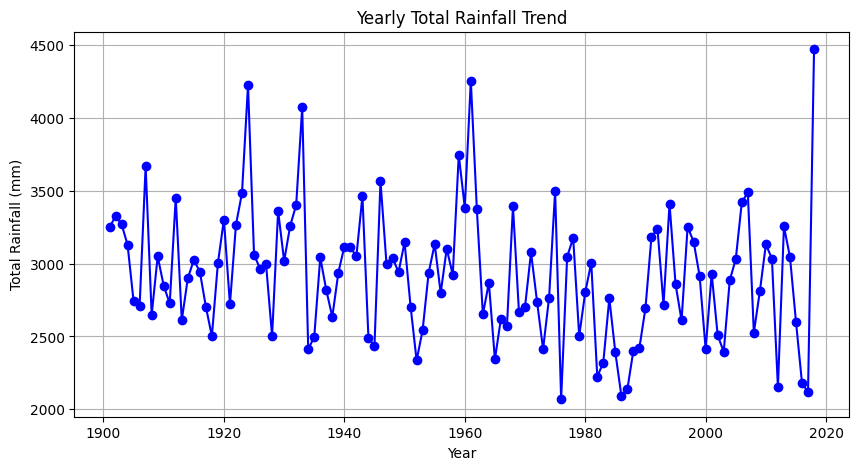

In [ ]:
df['ANNUAL'] = df[months].sum(axis=1)

plt.figure(figsize=(10,5))
plt.plot(df['YEAR'], df['ANNUAL'], marker='o', color='blue')
plt.title('Yearly Total Rainfall Trend')
plt.xlabel('Year')
plt.ylabel('Total Rainfall (mm)')
plt.grid(True)
plt.show()


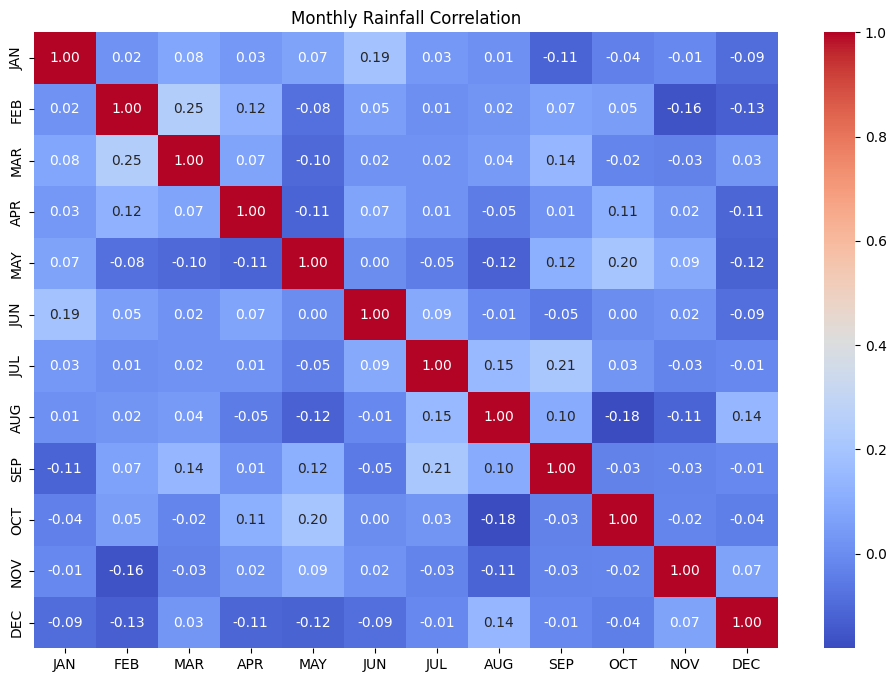

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(df[months].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Monthly Rainfall Correlation')
plt.show()


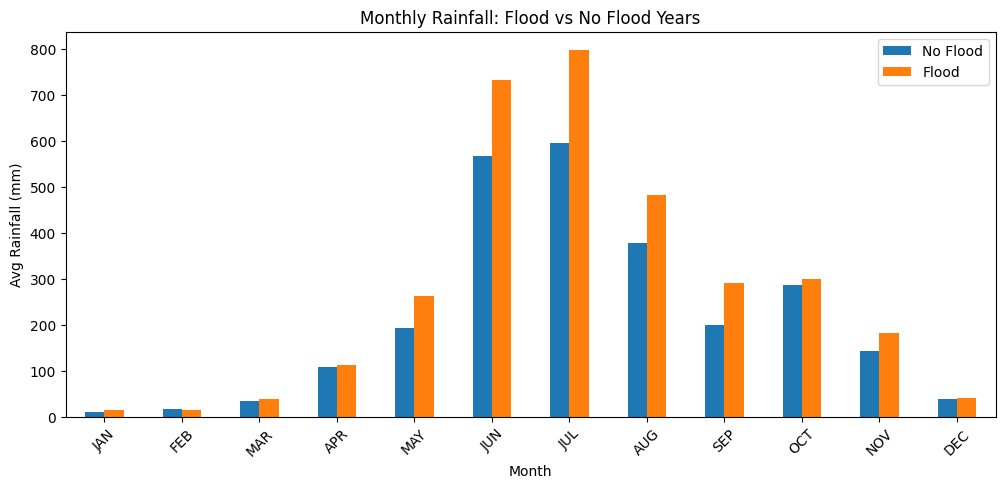

In [ ]:
df.groupby('FLOODS')[months].mean().T.plot(kind='bar', figsize=(12,5))
plt.title('Monthly Rainfall: Flood vs No Flood Years')
plt.xlabel('Month')
plt.ylabel('Avg Rainfall (mm)')
plt.xticks(rotation=45)
plt.legend(['No Flood', 'Flood'])
plt.show()


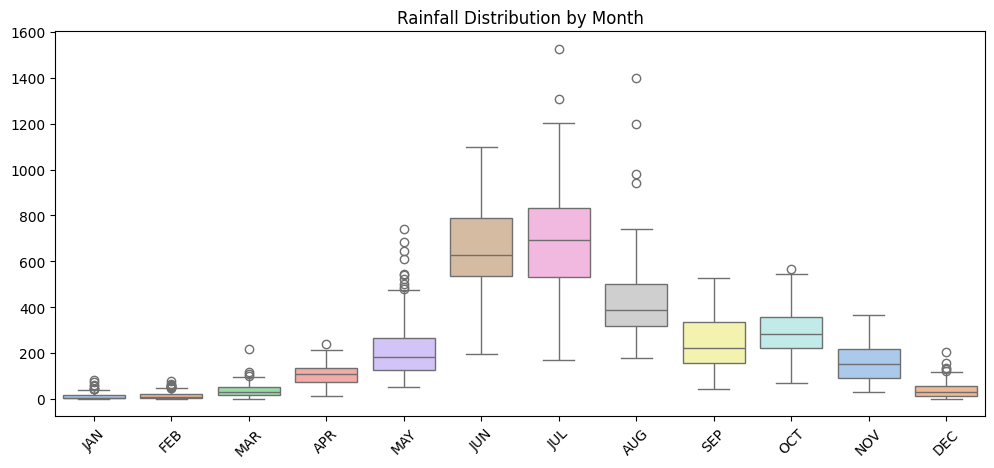

In [ ]:
plt.figure(figsize=(12,5))
sns.boxplot(data=df[months], palette='pastel')
plt.title('Rainfall Distribution by Month')
plt.xticks(rotation=45)
plt.show()


In [ ]:
print("Years with Flood:", df[df['FLOODS']=='YES']['YEAR'].values)
print("Years with No Flood:", df[df['FLOODS']=='NO']['YEAR'].values)
print("\nHighest Rainfall Year:", df.loc[df['ANNUAL'].idxmax(), 'YEAR'])
print("Lowest Rainfall Year:", df.loc[df['ANNUAL'].idxmin(), 'YEAR'])


Years with Flood: [1901 1902 1903 1904 1907 1909 1912 1915 1916 1919 1920 1922 1923 1924
 1925 1926 1927 1929 1930 1931 1932 1933 1936 1939 1940 1941 1942 1943
 1946 1947 1948 1949 1950 1954 1955 1957 1958 1959 1960 1961 1962 1968
 1971 1975 1977 1978 1981 1991 1992 1994 1997 1998 2005 2006 2007 2010
 2011 2013 2014 2018]
Years with No Flood: [1905 1906 1908 1910 1911 1913 1914 1917 1918 1921 1928 1934 1935 1937
 1938 1944 1945 1951 1952 1953 1956 1963 1964 1965 1966 1967 1969 1970
 1972 1973 1974 1976 1979 1980 1982 1983 1984 1985 1986 1987 1988 1989
 1990 1993 1995 1996 1999 2000 2001 2002 2003 2004 2008 2009 2012 2015
 2016 2017]

Highest Rainfall Year: 2018
Lowest Rainfall Year: 1976


In [ ]:
# Cell 12 - Prepare data
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

months = ['JAN','FEB','MAR','APR','MAY','JUN',
          'JUL','AUG','SEP','OCT','NOV','DEC']

X = df[months]
y = df['FLOODS'].map({'YES': 1, 'NO': 0})


In [ ]:
# Cell 13 - Train model
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

model = GaussianNB()
model.fit(X_train, y_train)


GaussianNB()

In [ ]:
# Cell 14 - Results
pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, pred) * 100, "%")


Accuracy: 79.16666666666666 %
